In [94]:
# Reproducible paper configuration
import time
import warnings
import threading
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from joblib import Parallel, delayed

from scipy.special import expit
from scipy.stats import t as student_t
from sklearn.base import clone, BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.kernel_approximation import RBFSampler
from imblearn.over_sampling import ADASYN

import importlib
import tg_vtss
importlib.reload(tg_vtss)
from tg_vtss import choose_tg_vtss_candidates, print_tg_vtss_summary

BASE_SEED = 123
REPETITIONS = 100
N_JOBS = 9  # Avoid BLAS oversubscription; set to 1 for sequential execution.
N0 = 800
D = 10
SETTINGS = [(1, 100)]  # sparse but locally estimable minority geometry
T_DF = 2.2  # extremely heavy tails, while retaining finite variance
T_SHIFT = 0.12  # modest global separation; overlap and nonlinear local geometry remain substantial
GAUSSIAN_SHIFT = 0.16
LOGNORMAL_LOG_SHIFT = 0.10
LOGNORMAL_SIGMA = 1.10  # heavy right tails without overwhelming all local geometry
OUTLIER_PROBABILITY = 0.10
OUTLIER_SCALE = 6.0
VISUALIZATION_SEED = 24680
N_TEST_PER_CLASS = 5_000
CV_FOLDS = 5
SMOTE_K = 3
TAU_GQS = 10
GQS_FOLDS = 3
RFF_COMPONENTS = 40  # moderate capacity after a preliminary 30-vs-80 screen
DIAGNOSTIC_COMPONENTS = 30
GAMMA_MULTIPLIERS = (0.5, 1.0, 2.0)
C_GRID = (1.0, 4.0)
COST_MULTIPLIERS = (1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0)  # actual minority-to-majority error-cost ratios
JITTER_SCALE = 0.08  # conservative fraction of the median within-minority 3-NN distance
MLP_HIDDEN = (64, 32)
MLP_EPOCHS = 120
MLP_LEARNING_RATE = 2e-3
MLP_WEIGHT_DECAY = 1e-3
torch.set_num_threads(1)  # reproducible, avoids nested thread oversubscription
TORCH_INIT_LOCK = threading.Lock()

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 13, "axes.titlesize": 15, "axes.labelsize": 14,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 10,
    "figure.titlesize": 18,
})

print({
    "seed": BASE_SEED, "repetitions": REPETITIONS, "n0": N0,
    "settings": SETTINGS, "cv_folds": CV_FOLDS,
    "tau_GQS": TAU_GQS, "GQS_folds": GQS_FOLDS,
})

{'seed': 123, 'repetitions': 100, 'n0': 800, 'settings': [(1, 100)], 'cv_folds': 5, 'tau_GQS': 10, 'GQS_folds': 3}


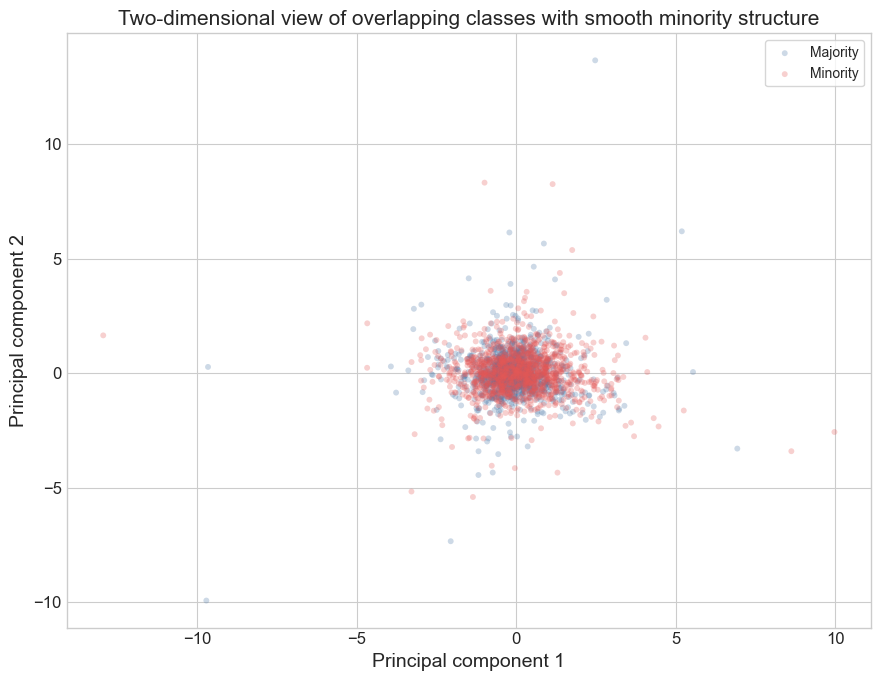

In [95]:
def _unit_directions(rng, n, d=D):
    z = rng.normal(size=(n, d))
    return z / np.maximum(np.linalg.norm(z, axis=1, keepdims=True), 1e-12)


def sample_mixed_class(rng, n, y):
    """Connected mixed-marginal classes with smooth local minority geometry."""
    direction = 1.0 if y == 1 else 0.0
    x_t = rng.standard_t(T_DF, size=(n, 3)) + direction*T_SHIFT
    gaussian_scale = np.where(rng.random((n, 3)) < OUTLIER_PROBABILITY, OUTLIER_SCALE, 1.0)
    x_gaussian = direction*GAUSSIAN_SHIFT + rng.normal(size=(n, 3))*gaussian_scale
    latent_lognormal = rng.normal(direction*LOGNORMAL_LOG_SHIFT, LOGNORMAL_SIGMA, size=(n, 4))

    if y == 1:
        # One connected, smoothly bent minority distribution. The sigmoid gate
        # strengthens continuously in sparsely observed heavy-tail regions.
        driver = x_t[:, 0]
        # A continuous curved tube, not disconnected clusters and not an oracle
        # generator target.  With only n1=100 its tails/boundary are sparsely
        # observed; local interpolation can smooth those gaps, whereas a single
        # global cost multiplier can only reweight the observed points.
        tail_gate = expit(2.2*(np.abs(driver)-0.65))
        local_strength = 0.70+0.30*expit(x_gaussian[:, 2])
        signed_tail = np.tanh(0.9*driver)*tail_gate*local_strength
        x_t[:, 1] += 1.35*np.tanh(0.8*driver)*local_strength
        x_t[:, 2] += 0.75*np.tanh(x_t[:, 1]-0.45*driver)
        x_gaussian[:, 0] += 1.45*signed_tail
        x_gaussian[:, 1] += 0.80*np.tanh(x_t[:, 1])
        latent_lognormal[:, 0] += 0.75*signed_tail
        latent_lognormal[:, 1] += 0.55*np.tanh(x_gaussian[:, 0])
    x_lognormal = np.exp(latent_lognormal)
    return np.hstack([x_t, x_gaussian, x_lognormal])


def sample_training(seed, K, n1, n0=N0):
    rng = np.random.default_rng(seed)
    X0 = sample_mixed_class(rng, n0, y=0)
    X1 = sample_mixed_class(rng, n1, y=1)
    return np.vstack([X0, X1]), np.r_[np.zeros(n0, dtype=int), np.ones(n1, dtype=int)]


def sample_balanced_test(seed, K, n_per_class=N_TEST_PER_CLASS):
    rng = np.random.default_rng(seed)
    X0 = sample_mixed_class(rng, n_per_class, y=0)
    X1 = sample_mixed_class(rng, n_per_class, y=1)
    return np.vstack([X0, X1]), np.r_[np.zeros(n_per_class, dtype=int), np.ones(n_per_class, dtype=int)]


# Reproducible two-dimensional view of the population covariate geometry.
X_visual, y_visual = sample_balanced_test(VISUALIZATION_SEED, K=1, n_per_class=1_200)
X_visual_2d = PCA(n_components=2, random_state=VISUALIZATION_SEED).fit_transform(
    StandardScaler().fit_transform(X_visual)
)
fig, ax = plt.subplots(figsize=(9, 7))
for label, name, color in [(0, "Majority", "#4C78A8"), (1, "Minority", "#E45756")]:
    keep = y_visual == label
    ax.scatter(X_visual_2d[keep, 0], X_visual_2d[keep, 1], s=18, alpha=0.28,
               color=color, edgecolors="none", label=name)
ax.set_xlabel("Principal component 1"); ax.set_ylabel("Principal component 2")
ax.set_title("Two-dimensional view of overlapping classes with smooth minority structure")
ax.legend(frameon=True); fig.tight_layout(); plt.show()


def smote_pool(X_minority, n_synthetic, seed, k=SMOTE_K):
    if n_synthetic <= 0:
        return np.empty((0, X_minority.shape[1]))
    if len(X_minority) < 2:
        raise ValueError("SMOTE needs at least two minority observations.")
    rng = np.random.default_rng(seed)
    k_eff = min(k, len(X_minority)-1)
    neighbors = NearestNeighbors(n_neighbors=k_eff+1).fit(X_minority)
    index = neighbors.kneighbors(return_distance=False)[:, 1:]
    base = rng.integers(0, len(X_minority), size=n_synthetic)
    pick = rng.integers(0, k_eff, size=n_synthetic)
    other = index[base, pick]
    lam = rng.random((n_synthetic, 1))
    return X_minority[base] + lam * (X_minority[other] - X_minority[base])


def jitter_pool(X_minority, n_synthetic, seed, k=SMOTE_K, scale=JITTER_SCALE):
    """Fast local generator using neighbor-calibrated isotropic Gaussian jitter."""
    if n_synthetic <= 0:
        return np.empty((0, X_minority.shape[1]))
    if len(X_minority) < 2:
        raise ValueError("Minority jitter needs at least two observations.")
    rng = np.random.default_rng(seed)
    k_eff = min(k, len(X_minority)-1)
    distances = NearestNeighbors(n_neighbors=k_eff+1).fit(X_minority).kneighbors()[0][:, 1:]
    local_scale = scale * np.median(distances, axis=1) / np.sqrt(X_minority.shape[1])
    base = rng.integers(0, len(X_minority), size=n_synthetic)
    noise = rng.normal(size=(n_synthetic, X_minority.shape[1]))
    return X_minority[base] + noise * local_scale[base, None]


def adasyn_pool(X, y, n_synthetic, seed, k=SMOTE_K):
    """Generate exactly n_synthetic minority points with standard imbalanced-learn ADASYN."""
    if n_synthetic <= 0:
        return np.empty((0, X.shape[1]))
    n_minority = int(np.sum(y == 1))
    k_eff = min(k, n_minority-1)
    # ADASYN rounds its per-observation allocations and can return fewer points
    # than the requested target. Use deterministic geometric overshoot, then
    # retain exactly the TG candidate size; every retained point is from ADASYN.
    requested = max(int(n_synthetic), int(np.ceil(1.10*n_synthetic))+k_eff+1)
    generated = np.empty((0, X.shape[1]))
    for attempt in range(20):
        sampler = ADASYN(
            sampling_strategy={1: n_minority + requested},
            n_neighbors=k_eff, random_state=int(seed)+attempt,
        )
        try:
            X_resampled, _ = sampler.fit_resample(X, y)
        except ValueError as exc:
            # For a small requested size, all integer ADASYN allocations can
            # round to zero. Increase the internal target and try again; the
            # returned pool is still truncated to the exact TG-VTSS size.
            if "No samples will be generated" not in str(exc):
                raise
            requested = max(2*requested, int(np.ceil(n_minority/2)))
            continue
        generated = X_resampled[len(X):]
        if len(generated) >= n_synthetic:
            return generated[:n_synthetic]
        deficit = int(n_synthetic)-len(generated)
        requested = max(requested+deficit+k_eff+1, int(np.ceil(1.35*requested)))
    raise RuntimeError(
        f"ADASYN generated only {len(generated)} of {n_synthetic} required points "
        f"after geometric target expansion to {requested}."
    )


def scale_gamma(X_scaled):
    return 1.0 / (X_scaled.shape[1] * max(float(np.var(X_scaled)), 1e-12))


def make_rff_map(X_real, gamma_multiplier, seed, components=RFF_COMPONENTS):
    scaler = StandardScaler().fit(X_real)
    Xs = scaler.transform(X_real)
    gamma = gamma_multiplier * scale_gamma(Xs)
    rff = RBFSampler(gamma=gamma, n_components=components, random_state=seed)
    rff.fit(Xs)
    return scaler, rff, gamma


def transform(map_tuple, X):
    scaler, rff, _ = map_tuple
    return rff.transform(scaler.transform(X))


def fit_ridge_logistic(Z, y, C, seed, sample_weight=None):
    clf = LogisticRegression(
        solver="lbfgs", C=C, max_iter=200, tol=1e-3,
        warm_start=True, random_state=seed,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        clf.fit(Z, y, sample_weight=sample_weight)
    return clf


def fit_mlp(Z, y, seed, sample_weight=None, epochs=MLP_EPOCHS):
    """Two-hidden-layer MLP trained with a consistently normalized weighted BCE loss."""
    # PyTorch's RNG is process-global: lock construction so parallel repetitions cannot race.
    with TORCH_INIT_LOCK:
        torch.manual_seed(int(seed))
        model = torch.nn.Sequential(
            torch.nn.Linear(Z.shape[1], MLP_HIDDEN[0]), torch.nn.ReLU(),
            torch.nn.Linear(MLP_HIDDEN[0], MLP_HIDDEN[1]), torch.nn.ReLU(),
            torch.nn.Linear(MLP_HIDDEN[1], 1),
        )
    optimizer = torch.optim.AdamW(model.parameters(), lr=MLP_LEARNING_RATE, weight_decay=MLP_WEIGHT_DECAY)
    Xt = torch.as_tensor(Z, dtype=torch.float32)
    yt = torch.as_tensor(y[:, None], dtype=torch.float32)
    weight = np.ones(len(y)) if sample_weight is None else np.asarray(sample_weight)
    wt = torch.as_tensor(weight[:, None], dtype=torch.float32)
    for _ in range(epochs):
        optimizer.zero_grad()
        individual = torch.nn.functional.binary_cross_entropy_with_logits(model(Xt), yt, reduction="none")
        loss = (individual * wt).sum() / wt.sum()
        loss.backward(); optimizer.step()
    return model


def mlp_predict_proba(model, Z):
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(torch.as_tensor(Z, dtype=torch.float32))).cpu().numpy().ravel()


class TorchMLPEstimator(BaseEstimator, ClassifierMixin):
    """Sklearn-compatible wrapper used by the TG diagnosis and cross-fitting."""
    def __init__(self, seed=0, epochs=MLP_EPOCHS):
        self.seed, self.epochs = seed, epochs

    def fit(self, X, y, sample_weight=None):
        self.classes_ = np.array([0, 1])
        self.scaler_ = StandardScaler().fit(X)
        self.model_ = fit_mlp(self.scaler_.transform(X), np.asarray(y), self.seed, sample_weight, self.epochs)
        return self

    def predict_proba(self, X):
        p = mlp_predict_proba(self.model_, self.scaler_.transform(X))
        return np.c_[1-p, p]

    def diagnostic_features(self, X):
        Z = torch.as_tensor(self.scaler_.transform(X), dtype=torch.float32)
        with torch.no_grad():
            hidden = torch.relu(self.model_[0](Z))
            hidden = torch.relu(self.model_[2](hidden)).cpu().numpy()
        return np.c_[hidden, np.ones(len(hidden))]


_original_scores_and_hessians = tg_vtss._scores_and_hessians
def _mlp_aware_scores_and_hessians(model, X, y):
    if not isinstance(model, TorchMLPEstimator):
        return _original_scores_and_hessians(model, X, y)
    p = np.clip(model.predict_proba(X)[:, 1], 1e-10, 1-1e-10)
    features = model.diagnostic_features(X)
    scores = (p-np.asarray(y))[:, None] * features
    hessians = p[:, None, None]*(1-p)[:, None, None]*features[:, :, None]*features[:, None, :]
    return scores, hessians
tg_vtss._scores_and_hessians = _mlp_aware_scores_and_hessians


def balanced_class_weights(y):
    """Fixed inverse-frequency weights: each class has total weight one half."""
    n0, n1 = np.sum(y == 0), np.sum(y == 1)
    raw = np.where(y == 0, 0.5/n0, 0.5/n1)
    return raw * len(y) / raw.sum()


def cost_sensitive_weights(y, minority_error_cost):
    """Actual error-cost ratio, without an additional prevalence correction.

    A value c means that a minority error receives c times the weight of a
    majority error. The previous implementation multiplied c by n0/n1 as well,
    unintentionally combining fixed class balancing with cost sensitivity.
    """
    raw = np.where(y == 0, 1.0, float(minority_error_cost))
    return raw * len(y) / raw.sum()


def oversampling_weights(n_real, n_total):
    return np.full(n_total, n_real / n_total)


def balanced_logloss(y, p, eps=1e-12):
    """Numerically stable class-balanced binary log loss.

    MLP probabilities are float32 and can saturate at exactly zero or one.
    Convert before clipping and select the observed-class term directly, avoiding
    undefined products such as 0*log(0).
    """
    y = np.asarray(y, dtype=int)
    p = np.clip(np.asarray(p, dtype=np.float64), eps, 1.0-eps)
    loss = np.where(y == 1, -np.log(p), -np.log1p(-p))
    return float(0.5*loss[y == 0].mean() + 0.5*loss[y == 1].mean())


def generator_geometry(Xsyn, X_minority):
    if len(Xsyn) == 0:
        return {"invalid_lognormal_fraction":0.0, "standardized_mean_shift":np.nan, "covariance_distortion":np.nan}
    scale = np.maximum(X_minority.std(axis=0, ddof=1), 1e-8)
    mean_shift = np.linalg.norm((Xsyn.mean(0)-X_minority.mean(0))/scale) / np.sqrt(Xsyn.shape[1])
    real_cov, syn_cov = np.cov(X_minority, rowvar=False), np.cov(Xsyn, rowvar=False)
    cov_distortion = np.linalg.norm(syn_cov-real_cov, ord="fro") / max(np.linalg.norm(real_cov, ord="fro"), 1e-8)
    return {"invalid_lognormal_fraction":float(np.mean(np.any(Xsyn[:, 6:] <= 0, axis=1))),
            "standardized_mean_shift":float(mean_shift), "covariance_distortion":float(cov_distortion)}


In [96]:
def diagnostic_pipeline(X_real, gamma_multiplier=None, C=None, seed=0):
    # Same standardized two-hidden-layer MLP family as every final predictor.
    return TorchMLPEstimator(seed=seed, epochs=MLP_EPOCHS)


def choose_shared_hyperparameters(X, y, folds, seed):
    # Architecture and optimizer are frozen before the paired experiment.
    return {"gamma_multiplier": np.nan, "C": np.nan, "cv_loss": np.nan}


GENERATOR_SPECS = {
    "SMOTE": lambda X, y, n, seed: smote_pool(X[y == 1], n, seed, k=SMOTE_K),
    "Jitter": lambda X, y, n, seed: jitter_pool(X[y == 1], n, seed, k=SMOTE_K),
    "ADASYN": lambda X, y, n, seed: adasyn_pool(X, y, n, seed, k=SMOTE_K),
}


def tune_methods(X, y, folds, tg_candidates, shared, seed):
    gap = int(np.sum(y == 0) - np.sum(y == 1))
    method_losses = {"Raw ERM": [], "Class reweighting": []}
    weight_losses = {a: [] for a in COST_MULTIPLIERS}
    tg_sizes = {g: sorted(set(map(int, sizes))) for g, sizes in tg_candidates.items()}
    tg_losses = {g: {n: [] for n in sizes} for g, sizes in tg_sizes.items()}

    for fold, (train, val) in enumerate(folds):
        Xtr, ytr, Xv, yv = X[train], y[train], X[val], y[val]
        fold_seed = seed + 10_000 + fold
        scaler = StandardScaler().fit(Xtr)
        Ztr, Zv = scaler.transform(Xtr), scaler.transform(Xv)
        n0f, n1f = int(np.sum(ytr == 0)), int(np.sum(ytr == 1))
        gapf = n0f-n1f

        raw = fit_mlp(Ztr, ytr, fold_seed)
        p_raw = mlp_predict_proba(raw, Zv)
        method_losses["Raw ERM"].append(balanced_logloss(yv, p_raw))

        rw = fit_mlp(Ztr, ytr, fold_seed, sample_weight=balanced_class_weights(ytr))
        method_losses["Class reweighting"].append(balanced_logloss(yv, mlp_predict_proba(rw, Zv)))

        for a in COST_MULTIPLIERS:
            cost_clf = fit_mlp(Ztr, ytr, fold_seed, sample_weight=cost_sensitive_weights(ytr, a))
            p_weighted = mlp_predict_proba(cost_clf, Zv)
            weight_losses[a].append(balanced_logloss(yv, p_weighted))

        for g_index, (generator_name, generator) in enumerate(GENERATOR_SPECS.items()):
            fold_sizes = {n: int(round((n/gap)*gapf)) if gap > 0 else 0 for n in tg_sizes[generator_name]}
            # Generate in the same standardized geometry used by the MLP.
            # Raw heavy-tailed/lognormal coordinates otherwise dominate Euclidean neighbors.
            Zsyn = generator(Ztr, ytr, max(fold_sizes.values()), fold_seed+999+100*g_index)
            for full_size in tg_sizes[generator_name]:
                nf = fold_sizes[full_size]
                Za = np.vstack([Ztr, Zsyn[:nf]])
                ya = np.r_[ytr, np.ones(nf, dtype=int)]
                weights = oversampling_weights(len(ytr), len(ya))
                size_clf = fit_mlp(Za, ya, fold_seed, sample_weight=weights)
                tg_losses[generator_name][full_size].append(
                    balanced_logloss(yv, mlp_predict_proba(size_clf, Zv))
                )

    # This is ordinary training-fold CV: no test outcomes or test covariates enter
    # cost-ratio selection. The tuned number is now the actual minority-to-majority
    # error-cost ratio, rather than inverse-frequency balancing multiplied by a
    # second factor. This keeps the comparator interpretable and avoids double weighting.
    best_cost_a = min(weight_losses, key=lambda a: np.mean(weight_losses[a]))
    best_tg = {g: min(losses, key=lambda n: np.mean(losses[n])) for g, losses in tg_losses.items()}
    return {
        "cost_multiplier": float(best_cost_a),
        "tg_sizes": {g: int(n) for g, n in best_tg.items()},
        "cv_losses": {
            "Raw ERM": float(np.mean(method_losses["Raw ERM"])),
            "Class reweighting": float(np.mean(method_losses["Class reweighting"])),
            "Tuned cost-sensitive": float(np.mean(weight_losses[best_cost_a])),
            **{f"TG-VTSS-{g}": float(np.mean(tg_losses[g][best_tg[g]])) for g in GENERATOR_SPECS},
        },
    }

In [97]:
METHOD_ORDER = [
    "Raw ERM", "Class reweighting", "Tuned cost-sensitive",
    "TG-VTSS-SMOTE", "TG-VTSS-Jitter", "TG-VTSS-ADASYN",
]


def fit_and_predict_all(X, y, X_test, shared, tuning, seed):
    scaler = StandardScaler().fit(X)
    Z, Ztest = scaler.transform(X), scaler.transform(X_test)
    predictions = {}
    final_seed = seed + 51_000  # identical initial weights for every final method
    raw = fit_mlp(Z, y, final_seed)
    predictions["Raw ERM"] = (mlp_predict_proba(raw, Ztest), 0.5)
    rw = fit_mlp(Z, y, final_seed, sample_weight=balanced_class_weights(y))
    predictions["Class reweighting"] = (mlp_predict_proba(rw, Ztest), 0.5)
    cost = fit_mlp(Z, y, final_seed, sample_weight=cost_sensitive_weights(y, tuning["cost_multiplier"]))
    predictions["Tuned cost-sensitive"] = (mlp_predict_proba(cost, Ztest), 0.5)
    for g_index, (generator_name, generator) in enumerate(GENERATOR_SPECS.items()):
        method, n_syn = f"TG-VTSS-{generator_name}", tuning["tg_sizes"][generator_name]
        if n_syn == 0:
            Za, ya = Z, y
        else:
            # Fit the generator in standardized model space, exactly as in CV.
            Zsyn = generator(Z, y, n_syn, seed+52_000+100*g_index)
            Za, ya = np.vstack([Z, Zsyn]), np.r_[y, np.ones(n_syn, dtype=int)]
        clf = fit_mlp(Za, ya, final_seed, sample_weight=oversampling_weights(len(y), len(ya)))
        predictions[method] = (mlp_predict_proba(clf, Ztest), 0.5)
    return predictions


def run_repetition(K, n1, rep, X_test, y_test, base_seed=BASE_SEED):
    seed = int(np.random.SeedSequence([base_seed, K, n1, rep]).generate_state(1)[0])
    X, y = sample_training(seed, K, n1)
    folds = list(StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed+100).split(X, y))
    shared = choose_shared_hyperparameters(X, y, folds, seed)
    decisions = {}
    for g_index, (generator_name, generator) in enumerate(GENERATOR_SPECS.items()):
        def diagnostic_generator(Xr, yr, n_synthetic, generator_seed, _generator=generator):
            diagnostic_scaler = StandardScaler().fit(Xr)
            Zr = diagnostic_scaler.transform(Xr)
            Zsyn = _generator(Zr, yr, n_synthetic, generator_seed)
            return diagnostic_scaler.inverse_transform(Zsyn)
        estimator = diagnostic_pipeline(X, seed=seed+200)
        decisions[generator_name] = choose_tg_vtss_candidates(X, y, estimator, diagnostic_generator, tau_gqs=TAU_GQS, folds=GQS_FOLDS, seed=seed+300+100*g_index)
    # Use Algorithm 1 candidates exactly. The previous min(gap, n) cap wrongly
    # removed wide candidates when a generator was diagnosed as biased and could
    # also truncate a valid theory-centered candidate above balance.
    tg_candidates = {
        generator_name: sorted(set(map(int, decision.candidate_sizes)))
        for generator_name, decision in decisions.items()
    }
    tuning = tune_methods(X, y, folds, tg_candidates, shared, seed)
    predictions = fit_and_predict_all(X, y, X_test, shared, tuning, seed)
    rows=[]
    for method in METHOD_ORDER:
        p, _ = predictions[method]
        generator_name = method.removeprefix("TG-VTSS-") if method.startswith("TG-VTSS-") else None
        decision = decisions.get(generator_name)
        if generator_name:
            g_index = list(GENERATOR_SPECS).index(generator_name)
            geometry_size = int(tuning["tg_sizes"][generator_name])
            if geometry_size == 0:
                # StandardScaler.inverse_transform rejects an empty matrix, while
                # generator_geometry intentionally supports a zero-size TG choice.
                diagnostic_pool = np.empty((0, X.shape[1]), dtype=float)
            else:
                geometry_scaler = StandardScaler().fit(X)
                diagnostic_pool_scaled = GENERATOR_SPECS[generator_name](
                    geometry_scaler.transform(X), y, geometry_size,
                    seed+52_000+100*g_index,
                )
                diagnostic_pool = geometry_scaler.inverse_transform(
                    diagnostic_pool_scaled
                )
            geometry = generator_geometry(diagnostic_pool, X[y == 1])
        else:
            geometry = {"invalid_lognormal_fraction":np.nan, "standardized_mean_shift":np.nan, "covariance_distortion":np.nan}
        rows.append({
            "K":K, "n1":n1, "rep":rep, "seed":seed, "setting":f"Mixed marginals, n1={n1}", "method":method,
            "shared_gamma_multiplier":shared["gamma_multiplier"], "shared_C":shared["C"],
            "cost_multiplier":tuning["cost_multiplier"] if method == "Tuned cost-sensitive" else np.nan,
            # Cross-validated balanced log loss used to select this method's tuning parameter.
            # This is distinct from balanced_logloss below, which is evaluated on the test set.
            "cv_balanced_logloss":tuning["cv_losses"].get(method, np.nan),
            "selected_synthetic_size":tuning["tg_sizes"].get(generator_name, 0),
            "tg_regime":decision.regime if decision else None, "tg_generator":decision.generator_decision if decision else None,
            "gqs":decision.gqs if decision else np.nan, **geometry,
            "balanced_logloss": balanced_logloss(y_test, p),
        })
    return rows, decisions

In [98]:
def run_simulation(repetitions=REPETITIONS, base_seed=BASE_SEED, n_jobs=N_JOBS):
    test_sets = {}
    for K, n1 in SETTINGS:
        test_seed = int(np.random.SeedSequence([base_seed, 999, K, n1]).generate_state(1)[0])
        test_sets[(K, n1)] = sample_balanced_test(test_seed, K)
    tasks = [(K, n1, rep) for K, n1 in SETTINGS for rep in range(repetitions)]
    start = time.time()
    outputs = Parallel(n_jobs=n_jobs, prefer="threads", verbose=10)(
        delayed(run_repetition)(
            K, n1, rep, test_sets[(K, n1)][0], test_sets[(K, n1)][1], base_seed
        )
        for K, n1, rep in tasks
    )
    all_rows, decisions = [], []
    for (K, n1, rep), (rows, decision) in zip(tasks, outputs):
        all_rows.extend(rows)
        decisions.append({"K":K, "n1":n1, "rep":rep, "decision":decision})
    print(f"Finished {len(tasks)} repetitions in {time.time()-start:.1f}s")
    return pd.DataFrame(all_rows), decisions


results, tg_decisions = run_simulation(repetitions=REPETITIONS, n_jobs=N_JOBS)
print(f"Completed repetitions: {results.groupby(['K','n1'])['rep'].nunique().to_dict()}")

[Parallel(n_jobs=9)]: Using backend ThreadingBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   7 tasks      | elapsed: 31.4min
[Parallel(n_jobs=9)]: Done  14 tasks      | elapsed: 63.1min
[Parallel(n_jobs=9)]: Done  23 tasks      | elapsed: 96.6min
[Parallel(n_jobs=9)]: Done  32 tasks      | elapsed: 129.7min
[Parallel(n_jobs=9)]: Done  43 tasks      | elapsed: 164.8min
[Parallel(n_jobs=9)]: Done  54 tasks      | elapsed: 204.2min
[Parallel(n_jobs=9)]: Done  67 tasks      | elapsed: 272.9min
[Parallel(n_jobs=9)]: Done  80 tasks      | elapsed: 303.0min
[Parallel(n_jobs=9)]: Done  94 out of 100 | elapsed: 360.2min remaining: 23.0min


Finished 100 repetitions in 21811.4s
Completed repetitions: {(1, 100): 100}


[Parallel(n_jobs=9)]: Done 100 out of 100 | elapsed: 363.5min finished


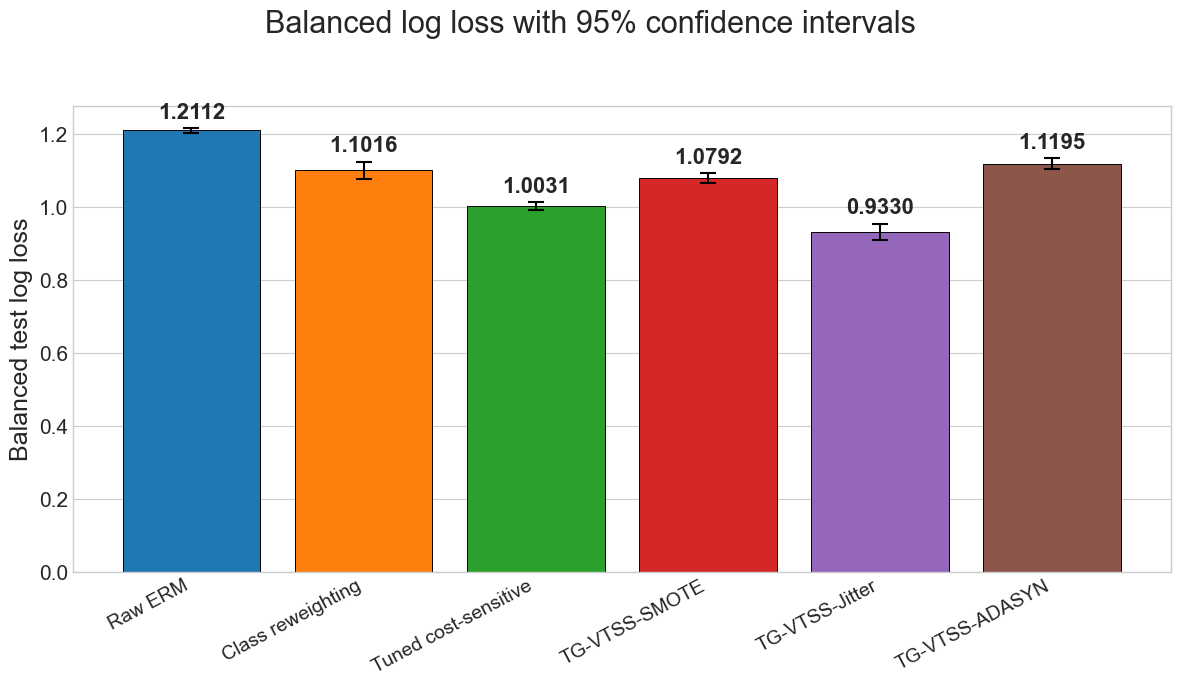

In [99]:
def summarize_balanced_logloss(results):
    rows = []
    for (setting, K, n1, method), part in results.groupby(
        ["setting", "K", "n1", "method"], sort=False
    ):
        values = part["balanced_logloss"].to_numpy(dtype=float)
        n = len(values)
        mean = float(values.mean())
        if n > 1:
            se = float(values.std(ddof=1) / np.sqrt(n))
            half_width = float(student_t.ppf(0.975, df=n-1) * se)
        else:
            se, half_width = np.nan, 0.0
        rows.append({
            "setting": setting, "K": K, "n1": n1, "method": method,
            "mean": mean, "se": se, "ci_half_width": half_width,
            "ci_low": mean-half_width, "ci_high": mean+half_width,
            "repetitions": n,
        })
    return pd.DataFrame(rows)


summary = summarize_balanced_logloss(results)
settings = [f"Mixed marginals, n1={n1}" for K, n1 in SETTINGS]
colors = dict(zip(METHOD_ORDER, plt.cm.tab10.colors[:len(METHOD_ORDER)]))
fig, axes = plt.subplots(
    1, len(settings), figsize=(max(12, 7*len(settings)), 7), squeeze=False
)
for ax, setting in zip(axes.flat, settings):
    plotted = (summary[summary.setting == setting]
               .set_index("method").reindex(METHOD_ORDER))
    x = np.arange(len(METHOD_ORDER))
    bars = ax.bar(
        x, plotted["mean"], yerr=plotted["ci_half_width"],
        color=[colors[m] for m in METHOD_ORDER], edgecolor="black",
        linewidth=0.7, capsize=6,
        error_kw={"elinewidth": 1.5, "capthick": 1.5},
    )
    ax.bar_label(
        bars, labels=[f"{value:.4f}" for value in plotted["mean"]],
        padding=4, fontsize=16, fontweight="bold",
    )
    ax.set_xticks(x, METHOD_ORDER, rotation=28, ha="right", fontsize=14)
    ax.set_ylabel("Balanced test log loss", fontsize=18)
    ax.tick_params(axis="y", labelsize=15)
    ax.grid(axis="x", visible=False)
fig.suptitle("Balanced log loss with 95% confidence intervals", fontsize=22)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [100]:
# TG-VTSS diagnostic summary accompanying the performance comparison.
diagnostic_summary = (
    results[results.method.str.startswith("TG-VTSS-")]
    .groupby(["setting","method","tg_regime","tg_generator"], dropna=False)
    .agg(
        repetitions=("rep","nunique"),
        mean_GQS=("gqs","mean"),
        mean_selected_size=("selected_synthetic_size","mean"),
        median_selected_size=("selected_synthetic_size","median"),
        mean_invalid_lognormal_fraction=("invalid_lognormal_fraction","mean"),
        mean_standardized_mean_shift=("standardized_mean_shift","mean"),
        mean_covariance_distortion=("covariance_distortion","mean"),
    )
    .reset_index()
)
display(diagnostic_summary)


,setting,method,tg_regime,tg_generator,repetitions,mean_GQS,mean_selected_size,median_selected_size,mean_invalid_lognormal_fraction,mean_standardized_mean_shift,mean_covariance_distortion
0,"Mixed marginals, n1=100",TG-VTSS-ADASYN,local asymmetry,biased generator,100,136.889009,225.40,70.0,0.00000,0.089659,0.540505
1,"Mixed marginals, n1=100",TG-VTSS-Jitter,local asymmetry,biased generator,100,130.709896,1049.30,1400.0,0.07208,0.042385,0.232799
2,"Mixed marginals, n1=100",TG-VTSS-SMOTE,local asymmetry,biased generator,100,136.073318,109.55,105.0,0.00000,0.092921,0.549358
